In [1]:
import numpy as np
import pandas as pd

#Visualization libraries:
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation library:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

#Deep learning libraries:
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier

In [2]:
fashion_train=pd.read_csv("fashion-mnist_train.csv")

In [4]:
fashion_test=pd.read_csv("fashion-mnist_test.csv")

In [6]:
fashion_train.shape

(60000, 785)

In [7]:
fashion_test.shape

(10000, 785)

In [10]:
X_train_fashion=fashion_train.drop('label',axis=1)
y_train_fashion=fashion_train['label']

In [13]:
X_test_fashion=fashion_test.drop('label',axis=1)
y_test_fashion=fashion_test['label']

In [14]:
#reshaping the dataset
X_train_reshape = X_train_fashion.values.reshape(-1,28,28) #-1 means all images
X_test_reshape = X_test_fashion.values.reshape(-1,28,28)

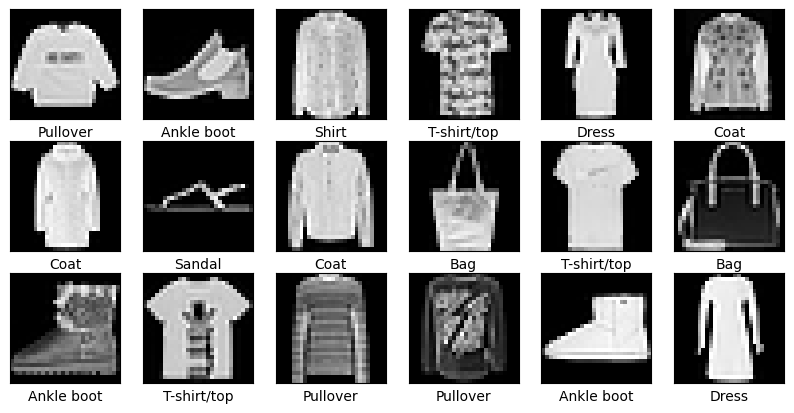

In [21]:
#names of the clothing accessoroes in order:
col_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
#Visualizing the image
plt.figure(figsize=(10,10))
for i in range(18): # will test for 18 images (range 0-17)
    plt.subplot(6,6,i+1) 
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_reshape[i], cmap='gray')
    plt.xlabel(col_names[y_train_fashion[i]])
plt.show()

In [22]:
#outout data encoding fashion mnist labels:
y_train_fashion=to_categorical(y_train_fashion,num_classes=10)
y_test_fashion=to_categorical(y_test_fashion,num_classes=10)

In [23]:
y_train_fashion

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], shape=(60000, 10))

In [24]:
y_test_fashion

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(10000, 10))

In [40]:
#creating base neural n/w
model = keras.Sequential([
    layers.Dense(256, activation='relu',input_shape=(784,)),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(24,activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(24,activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(10,activation='softmax'),
])

C:\Anaconda3\envs\AIML\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 24)                  │           6,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 24)                  │             600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │             250 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 209,194 (817.16 KB)

 Trainable params: 208,586 (814.79 KB)

 Non-trainable params: 608 (2.38 KB)

In [42]:
#compiling the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [43]:
#fitting the model
history=model.fit(X_train_fashion, y_train_fashion, batch_size =100, epochs=30, validation_data=(X_test_fashion, y_test_fashion))

Epoch 1/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.6491 - loss: 1.0680 - val_accuracy: 0.8228 - val_loss: 0.5341
Epoch 2/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7584 - loss: 0.7187 - val_accuracy: 0.8426 - val_loss: 0.4636
Epoch 3/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7785 - loss: 0.6562 - val_accuracy: 0.8434 - val_loss: 0.4590
Epoch 4/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7888 - loss: 0.6217 - val_accuracy: 0.8507 - val_loss: 0.4269
Epoch 5/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8018 - loss: 0.5925 - val_accuracy: 0.8543 - val_loss: 0.4597
Epoch 6/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8031 - loss: 0.5882 - val_accuracy: 0.8648 - val_loss: 0.4116
Epoch 7/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8079 - loss: 0.5721 - val_accuracy: 0.8678 - val_loss: 0.3992
Epoch 8/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8144 - loss: 0.5595 - val_a

In [31]:
test_loss_fashion,test_acc_fashion=model.evaluate(X_test_fashion,y_test_fashion)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8745 - loss: 0.3601


In [34]:
print("Final test accuracy:" , round(test_acc_fashion,2))

Final test accuracy: 0.87


In [36]:
y_predict_fashion = model.predict(X_test_fashion)
y_predict_fashion=np.argmax(y_predict_fashion, axis=1)
y_test_fashion_eval=np.argmax(y_test_fashion, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [37]:
y_predict_fashion

array([0, 1, 2, ..., 8, 8, 1], shape=(10000,))

In [38]:
y_predict_fashion

array([0, 1, 2, ..., 8, 8, 1], shape=(10000,))

In [39]:
y_test_fashion_eval

array([0, 1, 2, ..., 8, 8, 1], shape=(10000,))

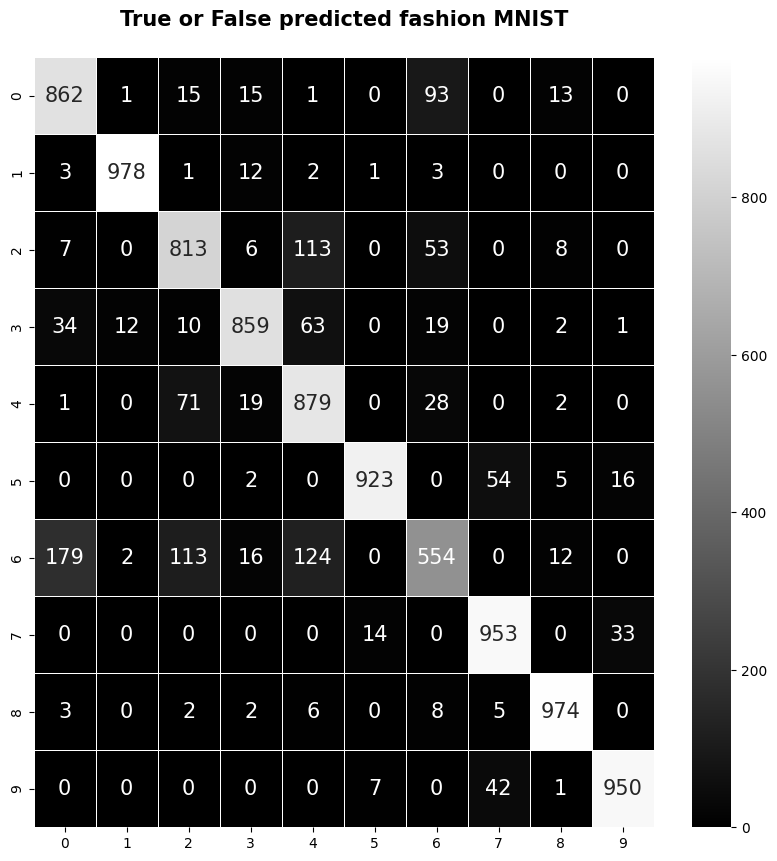

In [44]:
#confusion matrix for fashion  mnist
con_mat=confusion_matrix(y_test_fashion_eval,y_predict_fashion)
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidth=0.5,fmt='d',cmap='gray')
plt.title('True or False predicted fashion MNIST\n',fontweight='bold',fontsize=15)
plt.show()

In [45]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test_fashion_eval,y_predict_fashion))

              precision    recall  f1-score   support

           0       0.79      0.86      0.83      1000
           1       0.98      0.98      0.98      1000
           2       0.79      0.81      0.80      1000
           3       0.92      0.86      0.89      1000
           4       0.74      0.88      0.80      1000
           5       0.98      0.92      0.95      1000
           6       0.73      0.55      0.63      1000
           7       0.90      0.95      0.93      1000
           8       0.96      0.97      0.97      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



In [46]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


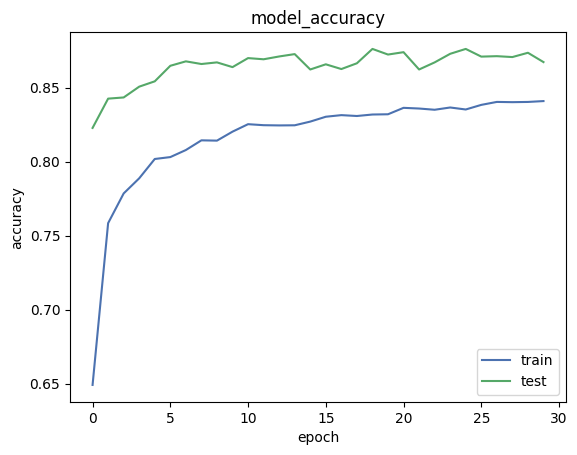

In [47]:
#summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model_accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'],loc='best')
plt.show()

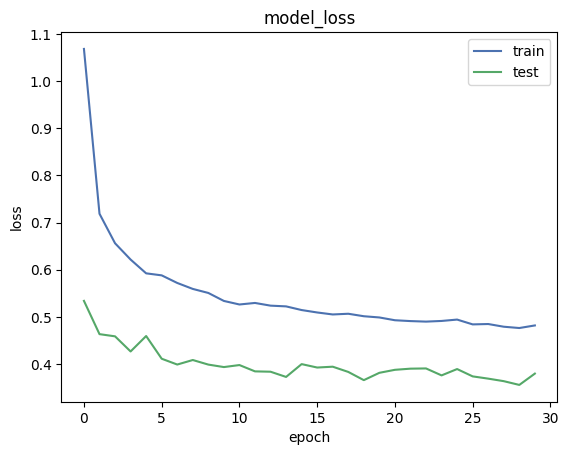

In [48]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','test'],loc='best')
plt.show()

In [52]:
#tf.expand_dims(X_test_digit[0])
y_predict = model.predict(X_test_fashion.loc[[0],:].values)
y_predict=np.argmax(y_predict,axis=1) #here we get the index of maximum value in the encoded vector
y_test_fashion_eval=np.argmax(y_test_fashion,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


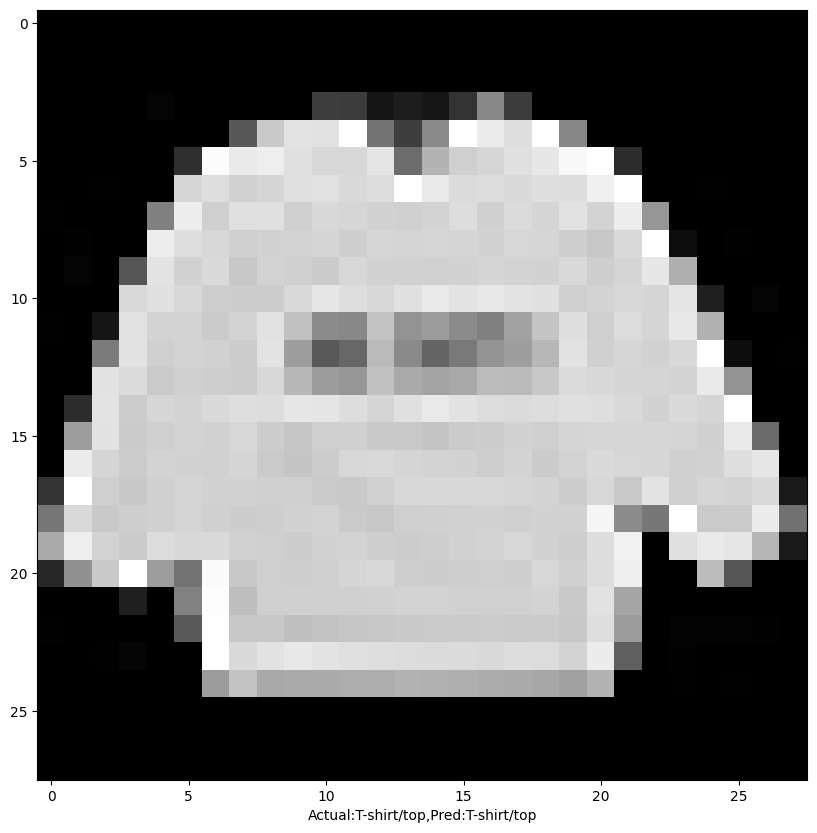

In [53]:
#names of the clothing accessoroes in order:
col_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
#Visualizing the image
plt.figure(figsize=(10,10))
plt.imshow(X_train_reshape[0], cmap='gray')
plt.xlabel('Actual:{},Pred:{}'.format(col_names[np.argmax(y_test_fashion[0])],col_names[y_predict[0]]))
plt.show()